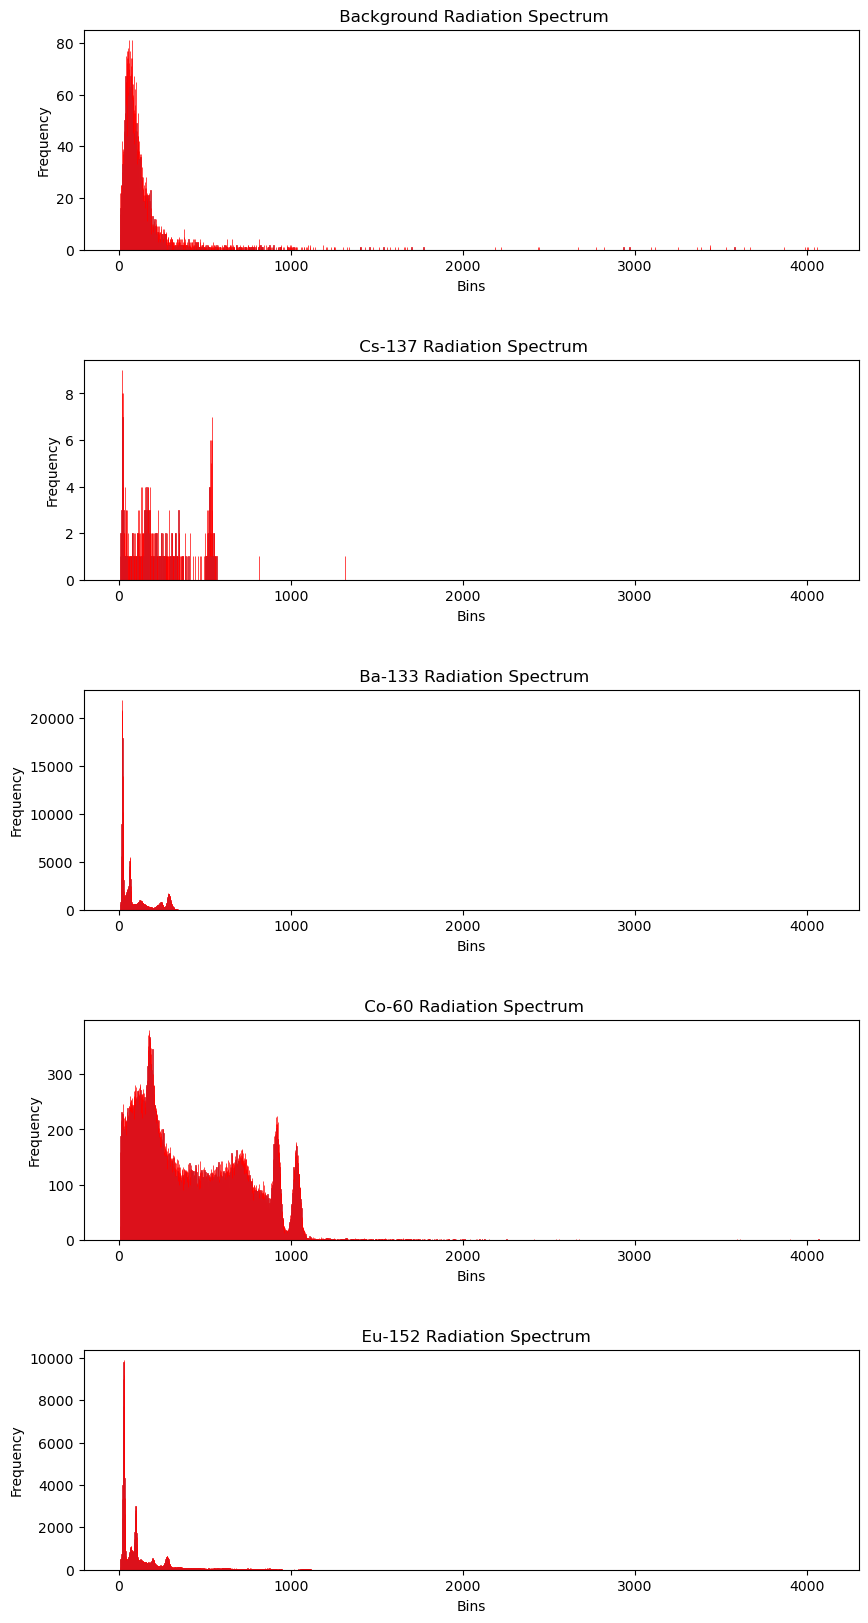

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

spectrum_data = [0,0,0,0,0]
isotopes = ["Background","Cs-137","Ba-133","Co-60"," Eu-152"]

spectrum_data[0] = pd.read_csv("data/calibrationdata/2026-04-22_15-48-56/spectrum.csv", skiprows=[0], header = None)
spectrum_data[1] = pd.read_csv("data/calibrationdata/2026-04-22_16-37-49/spectrum.csv", skiprows=[0], header = None)
spectrum_data[2] = pd.read_csv("data/calibrationdata/2026-04-22_16-52-09/spectrum.csv", skiprows=[0], header = None)
spectrum_data[3] = pd.read_csv("data/calibrationdata/2026-04-22_17-05-05/spectrum.csv", skiprows=[0], header = None)
spectrum_data[4] = pd.read_csv("data/calibrationdata/2026-04-22_17-17-20/spectrum.csv", skiprows=[0], header = None)



for i,data in enumerate(spectrum_data):

    # Remove timestamp column and get bin data
    data = data.drop(columns=[0])
    data = data.to_numpy().transpose()
    data = np.sum(data,axis=1)

    #log spectrum
    #data = np.log(data)
    spectrum_data[i] = data

bins = np.arange(1, spectrum_data[0].shape[0]+1)

fig, ax = plt.subplots(figsize=(10,20),nrows=5)
plt.subplots_adjust(hspace=0.5)

for i,data in enumerate(spectrum_data):

    #print(data)

    ax[i].bar(bins, data, width=1, align='edge', edgecolor='red', linewidth=0.5)
    ax[i].set_xlabel('Bins')
    ax[i].set_ylabel('Frequency')
    ax[i].set_title(f' {isotopes[i]} Radiation Spectrum')


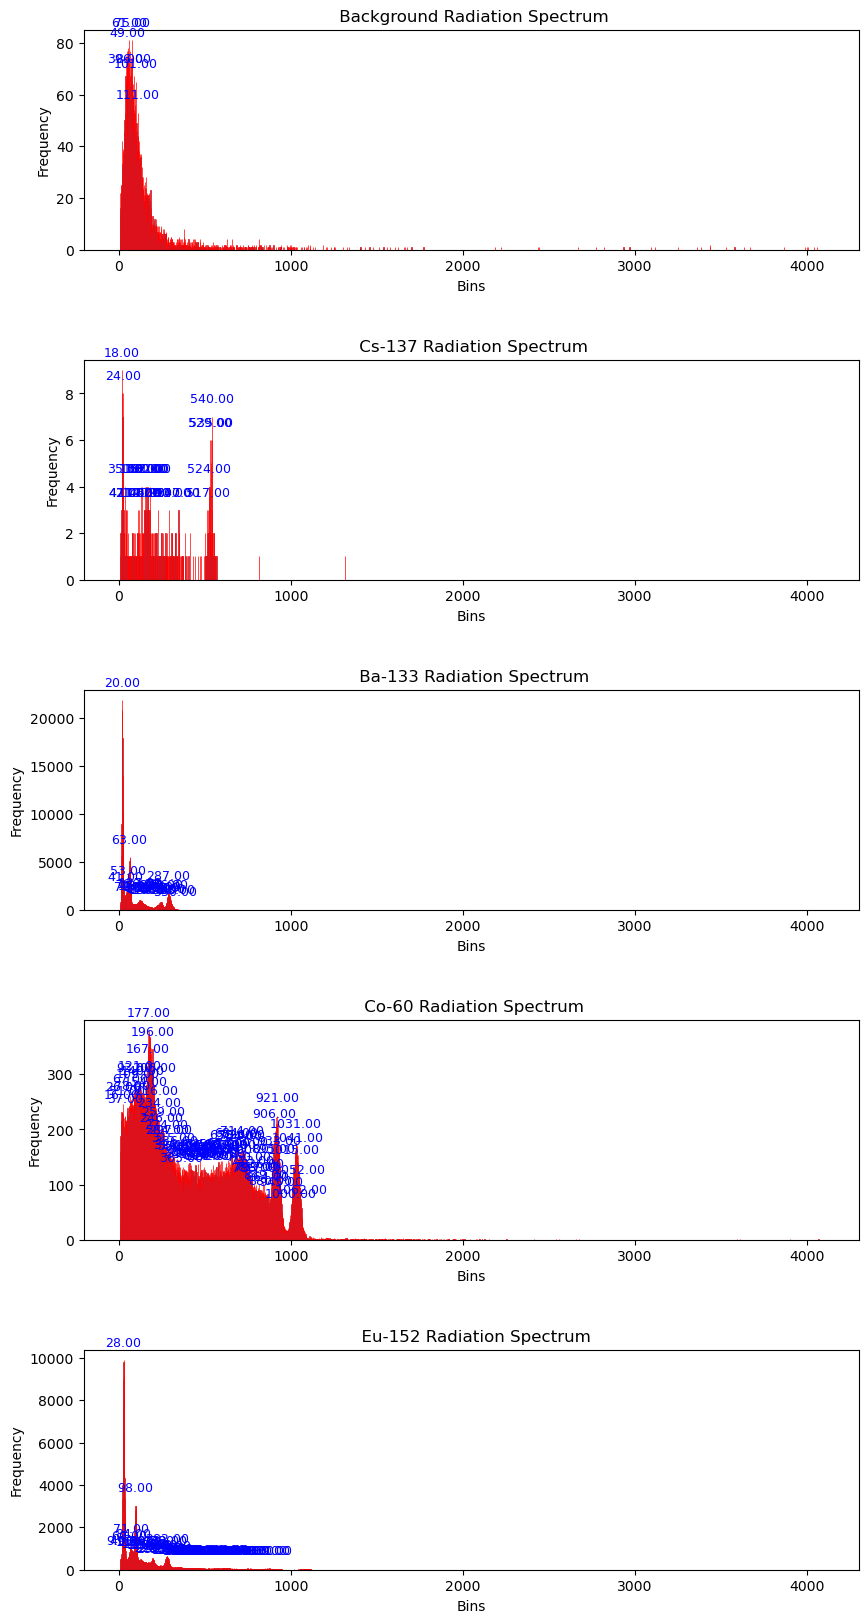

In [ ]:
from scipy.signal import find_peaks

fig, ax = plt.subplots(figsize=(10,20),nrows=5)
plt.subplots_adjust(hspace=0.5)


for i,data in enumerate(spectrum_data):

    if i == 1:
        peaks, _ = find_peaks(data, height=3, distance=5)
    else:
        peaks, _ = find_peaks(data, height=50, distance=10)

    bins = np.arange(1, data.shape[0]+1)

    ax[i].bar(bins, data, width=1, align='edge', edgecolor='red', linewidth=0.5)
    #ax[i].plot(bins, data=[peaks], color='red')

    for j in peaks:
    # xy=(x_coord, y_coord) is the point to annotate
    # textcoords="offset points" allows placing the label slightly above the peak
        ax[i].annotate(f"{bins[j]:.2f}", 
                 xy=(bins[j], data[j]), 
                 xytext=(0, 10), 
                 textcoords="offset points", 
                 ha='center', 
                 fontsize=9,
                 color='blue')

    ax[i].set_xlabel('Bins')
    ax[i].set_ylabel('Frequency')
    ax[i].set_title(f' {isotopes[i]} Radiation Spectrum')
    

#From this we get

#Bin - kEv
# 540 - 662
# 287 - 358
# 921 - 1173
# 1031 - 1332
# 177 - 209.8

#Conversion from bins-> kEv -- kEv = 1.30595 * x - 25.11782
# w/ R^2 value of 0.9994

    
